### ECMS  Equivalent Consumption Minimization Strategy

Unlike DP, ECMS does **not** solve a multi-stage recursion. At every timestep
$k$ it solves a **single-instant** minimization using only the present state
$(SoC(k), E_{ES2K}(k))$ no knowledge of the future.

**Equivalent fuel cost (instantaneous)**
$$
\dot{m}_{eq}(k) = \dot{m}_{ICE}(k) \;+\; \frac{s(k)}{H_{lhv}} \, P_{MGU\text{-}K}(k) + \frac{1}{H_{lhv}} \, \left ( \frac{P_{MGU\text{-}K}(k)}{U_{2}(SoC)}\right)^2\, R_{init}
$$

The first term is the real fuel burned by the ICE. The second term is a
*virtual* fuel cost assigned to using the battery, through the
**equivalence factor** $s(k)$: it converts a Joule of electrical energy into
an equivalent mass of fuel, so electrical and chemical energy can be compared
on the same footing at every instant, without knowledge of the rest of the lap.

**Per-step optimization problem**
$$
P_{MGU\text{-}K}^*(k) = \arg\min_{P_{MGU\text{-}K}(k) \,\in\, [lb(k),\,ub(k)]} \;
\dot{m}_{ICE}\big(P_{gb}(k) - P_{MGU\text{-}K}(k)\big) \;+\; \frac{s(k)}{H_{lhv}} P_{MGU\text{-}K}(k)+ \frac{1}{H_{lhv}} \, \left ( \frac{P_{MGU\text{-}K}(k)}{U_2(SoC)}\right)^2\, R_{init}
$$

**Bounds** identical physics to the DP formulation (regime-dependent: the ICE
cannot absorb negative power; excess braking power is dissipated by the
mechanical brakes at no fuel/energy cost):
$$
\begin{cases}
P_{gb}(k) - P_{ICE}^{max} \;\le\; P_{MGU\text{-}K}(k) \;\le\; P_{gb}(k), & P_{gb}(k) \ge 0\\[6pt]
P_{gb}(k) \;\le\; P_{MGU\text{-}K}(k) \;\le\; 0, & P_{gb}(k) < 0
\end{cases}
$$
together with, at every $k$:
$$
\begin{aligned}
P_{MGU\text{-}K}^{min} &\le P_{MGU\text{-}K}(k) \le P_{MGU\text{-}K}^{max} \\
\frac{(SoC^{max}-SoC(k))Q_{bat}\,U_{2}(SoC)}{-\Delta t} &\le P_{MGU\text{-}K}(k) \le \frac{(SoC^{min}-SoC(k))Q_{bat}\,U_{2}(SoC)}{-\Delta t} \\
P_{MGU\text{-}K}(k) &\le \frac{E_{ES2K}^{max} - E_{ES2K}(k)}{\Delta t}
\end{aligned}
$$
where $P_{ICE}^{max} = \eta_{ICE} H_{lhv} \dot{m}^{max} - P_{ICE,0}$ is the
**actually achievable** ICE power under the fuel-flow limit (not the nominal
regulatory $P_{ICE}^{max}$ this fixes the mismatch identified while reviewing
the DP bounds).

**State dynamics** (same as DP)
$$
\begin{aligned}
SoC(k+1) &= SoC(k) - \frac{\Delta t}{Q_{bat}\,U_{oc}(SoC)} P_{MGU\text{-}K}(k)\\
E_{ES2K}(k+1) &= E_{ES2K}(k) + \max(P_{MGU\text{-}K}(k),0)\,\Delta t
\end{aligned}
$$

**Calibration of $s$ (charge-sustaining constraint)**

$s$ is treated as a single constant over the lap (not adaptive a
deliberate first-iteration simplification, noted as future work). It is
found by bisection so that the simulated end-of-lap SoC matches the
initial SoC:
$$
\text{find } s \quad \text{s.t.} \quad SoC(N) = SoC(0)
$$
Intuition: raising $s$ makes battery use "more expensive" in the virtual
cost, so the controller draws less on the battery and ends the lap with a
higher SoC $SoC(N)$ is monotonic in $s$, which is what makes bisection
well posed.

In [9]:
import numpy as np
import matplotlib.pyplot as plot
from plant.parameters import params
import sys, os
sys.path.append(os.path.abspath('..'))

In [10]:
# Parameters (same convention as the DP notebook)
Delta_t = 0.1

Voc = params['V_oc_nom']
Q_bat = params['E_pack_capacity'] / Voc

P_MGU_max = params['P_MGU_max']   # 350 kW
P_MGU_min = params['P_MGU_min']   # -200 kW
P_eng_max_reg = params['P_ICE_max']  # 400 kW, nominal regulatory cap (NOT used as the bound ceiling, see below)

E_ES2K_max = params['E_deploy_max']  # 9 MJ

SOC_min = params['SoC_min']
SOC_max = params['SoC_max']

eta_ICE = params['eta_ICE']
P_ICE0 = params['P_ICE0']
LHV = params['LHV']
m_dot_max = params['m_dot_max'] / 3600.0  # kg/h -> kg/s
P_eng_max = params['P_ICE_max']   # 400[kW]

R_init = params['R_int']
Tbat = params['T_bat_init']


# Load Data: t, v, a
data = np.load('/app/Thermal-Aware-Energy-Management-System-for-a-Hybrid-Motorsport-Powertrain/data/Canada_qualifying.npy')
t = data[0,:]
v = data[1,:]
a = data[2,:]

# Load Data: power at the gearbox
data_of_power_gb = np.load('/app/Thermal-Aware-Energy-Management-System-for-a-Hybrid-Motorsport-Powertrain/data/power_domand.npy')
P_gb = data_of_power_gb[1,:]

N = len(t)

#### ECMS single-step solver

Given the current state and a fixed equivalence factor `s`, find the
`P_MGU-K(k)` that minimizes the equivalent fuel cost at this instant only.

In [11]:
from plant.battery import battery_step, coef_quad, Uoc

def ecms_bounds(P_gb_k,SoC_k, E_k, params_local, dt):
    """
    Regime-dependent admissible range for P_MGU-K(k). Uses Uoc(SoC_k)
    (open-circuit voltage, state-only) rather than U2 (terminal voltage),
    since U2 depends on the power being chosen and would make this circular.
    """
    Uoc_k = Uoc(SoC_k, coef_quad)

    soc_max_term = ((SOC_max - SoC_k) * Q_bat * Uoc_k) / -dt
    soc_min_term = ((SOC_min - SoC_k) * Q_bat * Uoc_k) / -dt
    E_deploy = (E_ES2K_max - E_k) / dt

    if P_gb_k >= 0:
        lb = max(soc_max_term, P_MGU_min, P_gb_k - P_eng_max)
        ub = min(soc_min_term, P_MGU_max, P_gb_k, E_deploy)
    else:
        lb = max(soc_max_term, P_MGU_min, P_gb_k)
        ub = min(soc_min_term, 0.0)

    return lb, ub


def ecms_step(P_gb_k, SoC_k, E_k, s, dt= Delta_t, n_grid=400):
    """
    Solve the single-instant ECMS minimization at time k.
    Returns: P_mguk_opt, P_eng_opt, m_dot_opt
    """
    
    
    lb, ub = ecms_bounds(P_gb_k, SoC_k, E_k, params ,dt)


    if ub < lb:
        P_mguk_opt = ub
        P_eng_opt = P_gb_k - P_mguk_opt if P_gb_k >= 0 else 0.0
        m_dot_opt = np.clip((P_eng_opt + P_ICE0) / (eta_ICE * LHV), 0.0, m_dot_max)
        P_eng_opt = m_dot_opt * eta_ICE * LHV - P_ICE0
        return P_mguk_opt, P_eng_opt, m_dot_opt

    P_mguk_grid = np.linspace(lb, ub, n_grid)

    if P_gb_k > 0:
        P_eng = P_gb_k - P_mguk_grid
        P_eng = np.clip(0, P_eng, P_eng_max)
    else:
        P_eng = np.zeros_like(P_mguk_grid)

    
    Uoc_k = Uoc(SoC_k, coef_quad) 
    m_dot = (P_eng + P_ICE0) / (eta_ICE * LHV)
    m_dot = np.clip(m_dot, 0.0, m_dot_max)

    # Equivalent cost: real fuel + virtual fuel cost of battery use
    J_eq = m_dot * dt + (s / LHV) * P_mguk_grid * dt + (1 / LHV) * (P_mguk_grid/Uoc_k )**2* dt

    idx = np.argmin(J_eq)
    return P_mguk_grid[idx], P_eng[idx], m_dot[idx]


#### Forward simulation with a fixed equivalence factor

In [12]:
SoC_ref = np.load('/app/Thermal-Aware-Energy-Management-System-for-a-Hybrid-Motorsport-Powertrain/data/SOC_DP_Canada_qualifying.npy')
def simulate_ECMS(SOC_0, E_0, P_gb, Kp, dt=Delta_t):
    N_local = len(P_gb)

    SoC_sim = np.zeros(N_local)
    E_ES2K_sim = np.zeros(N_local)
    P_MGUK_sim = np.zeros(N_local)
    P_eng_sim = np.zeros(N_local)
    m_dot_sim = np.zeros(N_local)
    J_sim = np.zeros(N_local)
    
    shortfall= np.zeros(N_local)

    SoC_sim[0] = SOC_0
    E_ES2K_sim[0] = E_0
    s_0 = 1
    for k in range(N_local - 1):

        s_k = s_0 - Kp*(SoC_sim[k]-SoC_ref[k])
        s_k = max(s_k,0.0)
        P_mguk_k, P_eng_k, m_dot_k = ecms_step(P_gb[k], SoC_sim[k], E_ES2K_sim[k], s_k, dt)

        P_MGUK_sim[k] = P_mguk_k
        P_eng_sim[k] = P_eng_k
        m_dot_sim[k] = m_dot_k
        J_sim[k] = m_dot_k * dt

        SoC_sim[k+1],_,_ = battery_step(SoC_sim[k], P_mguk_k, coef_quad, Tbat,params,dt)
        E_ES2K_sim[k+1] = E_ES2K_sim[k] + max(P_mguk_k, 0.0) * dt
        shortfall_t = P_gb[k] - (P_MGUK_sim[k]+P_eng_sim[k])
        if  P_gb[k]>0:
            shortfall[k] = P_gb[k] - (P_MGUK_sim[k]+P_eng_sim[k])
        else:
            shortfall[k]=0
    return P_MGUK_sim, P_eng_sim, m_dot_sim, J_sim, SoC_sim, E_ES2K_sim,shortfall


In [13]:
SOC_0 = 0.9
E_0 = 0.0
Kp = 170

P_MGUK_ecms, P_eng_ecms, m_dot_ecms, J_ecms, SoC_ecms, E_ES2K_ecms,shortfall = simulate_ECMS(SOC_0, E_0, P_gb,Kp)

print(f"Final SoC: {SoC_ecms[-2]:.4f}")
print(f"Total fuel consumed: {np.sum(J_ecms)*1e3:.2f} g")
print(f"Final deploy energy used: {E_ES2K_ecms[-2]/1e6:.3f} MJ (max {E_ES2K_max/1e6:.1f} MJ)")


Final SoC: 0.6008
Total fuel consumed: 690.73 g
Final deploy energy used: 6.606 MJ (max 9.0 MJ)


#### Plot ECMS results

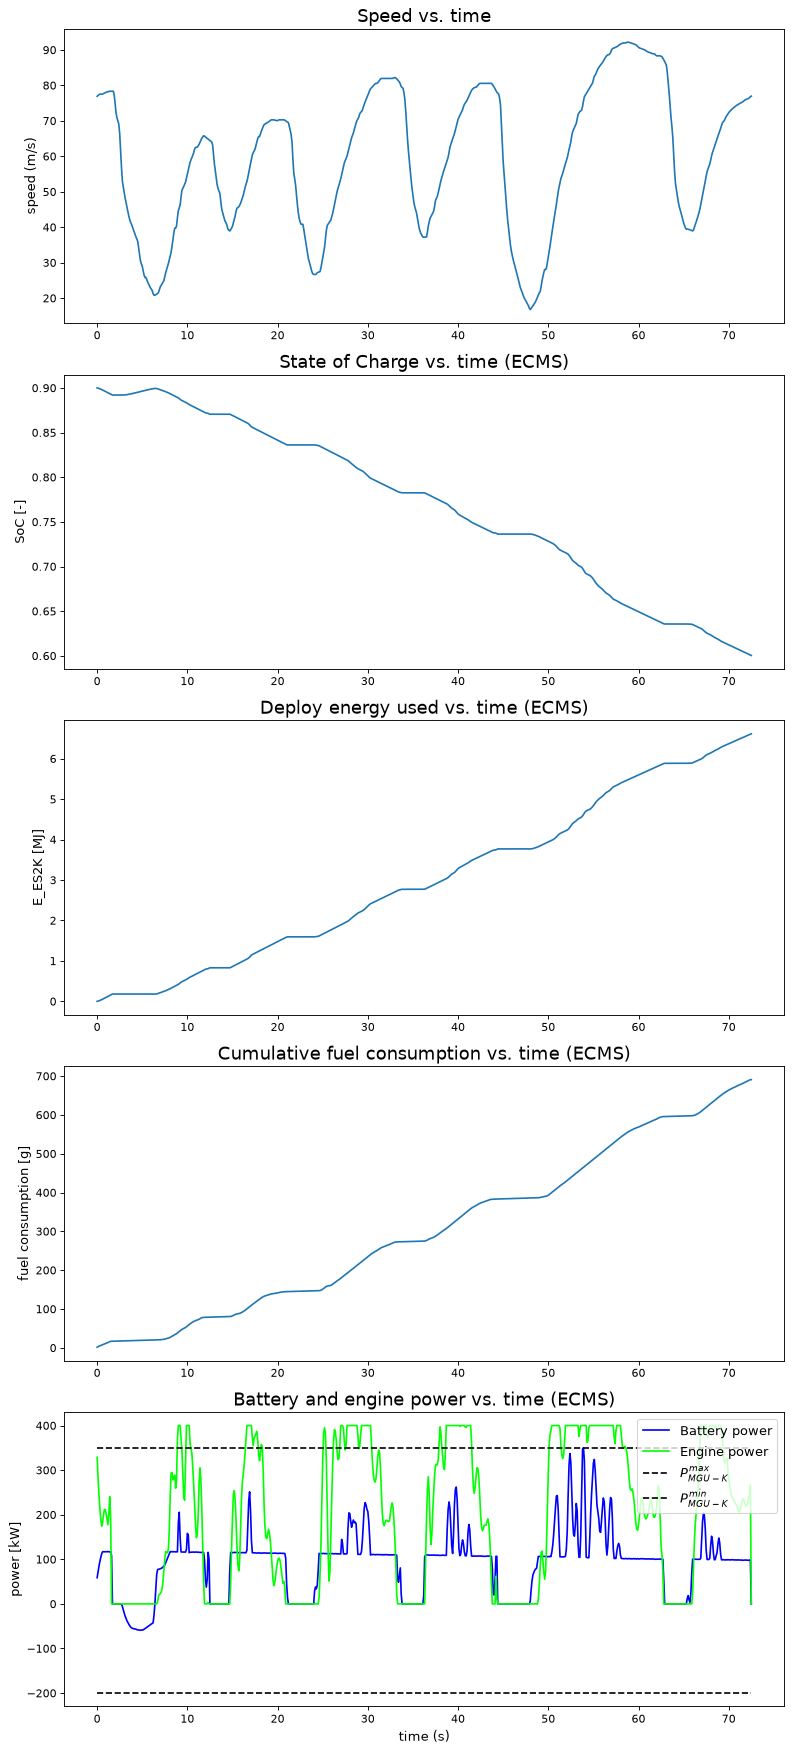

In [14]:
plot.figure(num=1, figsize=(10, 22), dpi=80, facecolor='w', edgecolor='k')

plot.subplot(5,1,1)
plot.plot(t, v)
plot.ylabel('speed (m/s)', fontsize=12)
plot.title('Speed vs. time', fontsize=16)

plot.subplot(5,1,2)
plot.plot(t, SoC_ecms)
plot.ylabel('SoC [-]', fontsize=12)
plot.title('State of Charge vs. time (ECMS)', fontsize=16)

plot.subplot(5,1,3)
plot.plot(t, E_ES2K_ecms/1e6)
plot.ylabel('E_ES2K [MJ]', fontsize=12)
plot.title('Deploy energy used vs. time (ECMS)', fontsize=16)

plot.subplot(5,1,4)
plot.plot(t, np.cumsum(J_ecms)*1e3)
plot.ylabel('fuel consumption [g]', fontsize=12)
plot.title('Cumulative fuel consumption vs. time (ECMS)', fontsize=16)

plot.subplot(5,1,5)
plot.plot(t, np.array(P_MGUK_ecms)/1e3, 'blue', label='Battery power')
plot.plot(t, np.array(P_eng_ecms)/1e3, 'lime', label='Engine power')
plot.plot(t, P_MGU_max/1e3*np.ones(t.shape), 'k--', label=r'$P_{MGU-K}^{max}$')
plot.plot(t, P_MGU_min/1e3*np.ones(t.shape), 'k--', label=r'$P_{MGU-K}^{min}$')
plot.ylabel('power [kW]', fontsize=12)
plot.xlabel('time (s)', fontsize=12)
plot.title('Battery and engine power vs. time (ECMS)', fontsize=16)
plot.legend(loc=1, fontsize=12)

plot.tight_layout()
plot.show()